# Feature Scaling - Standardization

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')

In [4]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


---

✅ **Drop non-numeric columns before scaling**

The Gender column contains string values (e.g., "Male", "Female"), which cannot be scaled directly using StandardScaler.

Therefore keep only numeric features: Age and EstimatedSalary.

---

In [5]:
df=df.iloc[:,2:]

In [6]:
df.sample(5)

,Age,EstimatedSalary,Purchased
290,39,134000,1
4,19,76000,0
329,47,107000,1
175,23,28000,0
98,35,73000,0


In [7]:
df.shape

(400, 3)

## Train test split

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

# StandardScaler

1. Its recommended you use Standard scaler after train test split
2. The standardscaler uses the formula

  $$
  z = \frac{x - \mu}{\sigma}
  $$

  where:

  * $x$ = original value
  * $\mu$ = mean
  * $\sigma$ = standard deviation


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train) # You ONLY learn from training data and ...

# transform train and test sets
X_train_scaled = scaler.transform(X_train) # ..but apply transform to both training
X_test_scaled = scaler.transform(X_test)   # .. and test set

⚠️ **IMPORTANT:**

You train the scaler from training set ONLY but apply the transform on both training and test sets

In [10]:
scaler.mean_ # Age Mean = 3.78642857e+01 and Salary Mean = 6.98071429e+04

array([3.78642857e+01, 6.98071429e+04])

In [11]:
# Retrieve the mean values learned
scaler_mean = scaler.mean_

# Show mean of each column in X_train
mean_age = X_train['Age'].mean()
mean_salary = X_train['EstimatedSalary'].mean()

scaler_mean, mean_age, mean_salary

(array([3.78642857e+01, 6.98071429e+04]),
 np.float64(37.864285714285714),
 np.float64(69807.14285714286))

---

Here's how the values for `scaler.mean_` were computed:

| Feature             | `scaler.mean_` value | Manually Computed Mean |
| ------------------- | -------------------- | ---------------------- |
| **Age**             | 37.864285714285714   | 37.864285714285714     |
| **EstimatedSalary** | 69,807.14285714286   | 69,807.14285714286     |

🔍 These are exactly the **means of the `X_train` data** that `StandardScaler` uses to perform Z-score standardization:

$$
z = \frac{x - \mu}{\sigma}
$$

---

In [12]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [13]:
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [14]:
# Convert the scaled NumPy arrays back to pandas DataFrames
# This is helpful so we can access the feature names (e.g., 'Age', 'EstimatedSalary')
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Apply the same column names to the test set as well
# Note: The scaler was fit only on the training set — this is important to avoid data leakage
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

---

### 🗣 From the video:


> 🔁 Once you transform the values using the scaler, if you don’t convert them back into a DataFrame, it becomes hard to understand.

> 🔁 Fit the scaler only on the training set... then use the same scaler to transform the test set.

These lines from the video reinforce two best practices:

* Restoring DataFrame structure after scaling for **clarity**
* Avoiding **data leakage** by scaling only using training statistics

---

In [15]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


### Describing before and after scaling

In [16]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [17]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


# Effect of Scaling

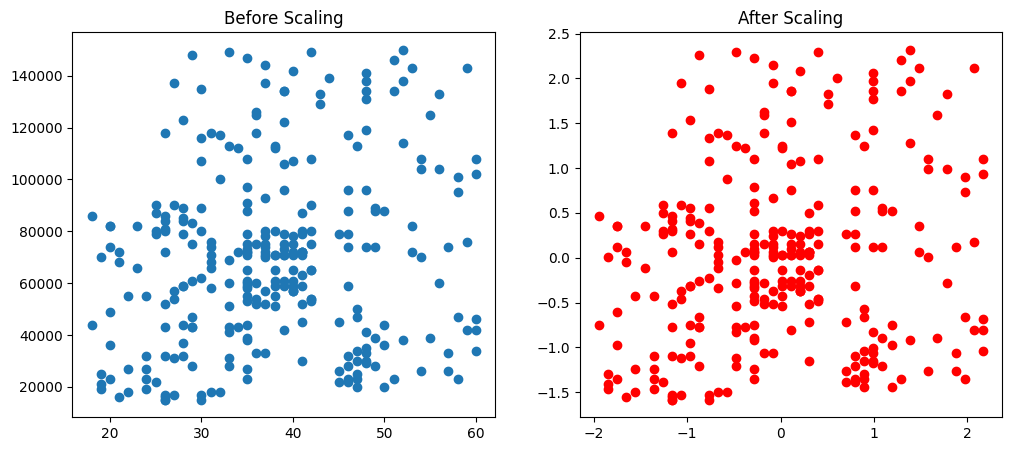

In [18]:
# Create a figure with two side-by-side plots
# ncols=2 means 2 columns (before and after scaling)
# figsize defines the width and height of the figure
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# ▶️ Plot original training data (unscaled)
# X-axis: Age, Y-axis: EstimatedSalary
# This shows how raw data is spread before applying Z-score normalization
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

# 🔁 Plot the same data after standardization
# Values are now transformed: mean ≈ 0, std dev ≈ 1
# The red points are the same people, but in standardized space
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title("After Scaling")

# 🖼️ Display the plots
plt.show()

---

> 🔁 Both plots look the same

> 🔁 If you plot salary and age together, they’ll appear in different scales...

> 🔁 After scaling... the whole dataset shifts near the origin... and the spread along both axes becomes equal.

> 🔁 So that the ML algorithm can treat both features equally.

This plot helps visualize the **geometric intuition**:

* **Before**: Age and Salary have very different magnitudes and spreads
* **After**: Both features are transformed to the **same scale**, centered around (0, 0)

---

### Comparing distributions together

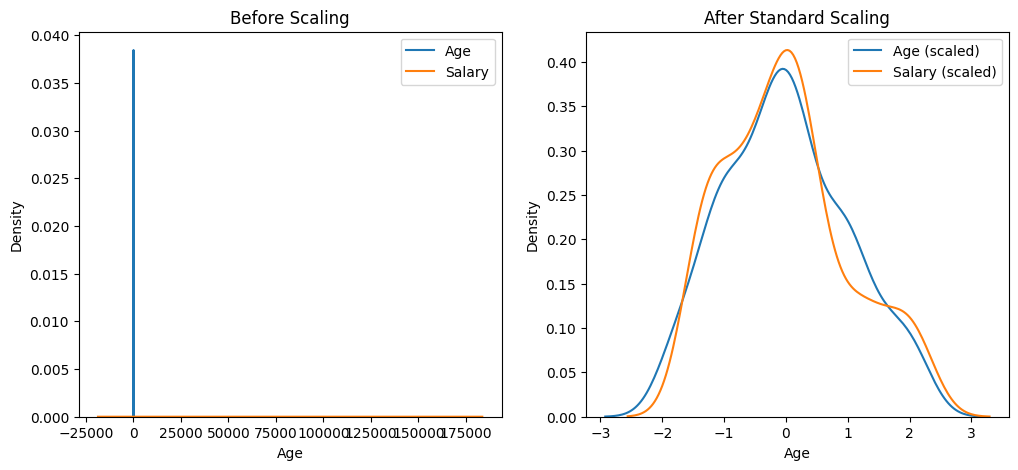

In [19]:
# Create two side-by-side plots to compare distributions
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# 📊 BEFORE SCALING: Plot KDE (smoothed density) of 'Age' and 'EstimatedSalary'
# This shows that the two features have different ranges and spreads
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1, label='Age')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, label='Salary')
ax1.legend()

# ⚖️ AFTER STANDARDIZATION: Plot KDE of the standardized features
# After scaling, both distributions are centered around 0, and have unit variance
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2, label='Age (scaled)')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, label='Salary (scaled)')
ax2.legend()

# Show the figure
plt.show()

---

> 🔁 After scaling, all the data comes near the origin.


> 🔁 Before scaling, Age and Salary were in different scales, making comparison difficult.


> 🔁 After standardization, the distributions of both become roughly equal.

This plot makes that shift **visually obvious**:

* The **left plot** shows how unscaled features have different centers and spreads.
* The **right plot** confirms that **both features are now centered around 0** and scaled to the same spread.

The scaled plot shows that distribution of Age and Salary are the same and are comparable.

---

### Comparison of Distributions individually

Its important to note that **individual** distributions does not change before and after standardization. Only scale changes

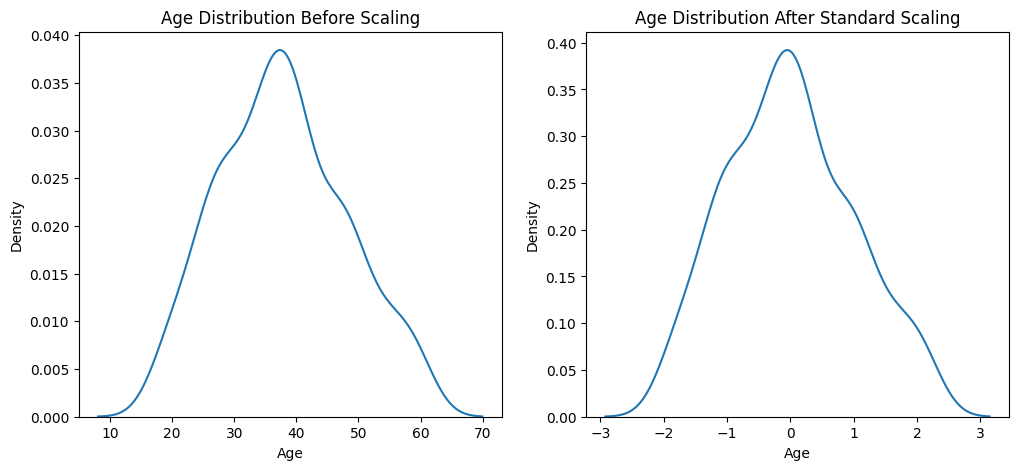

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

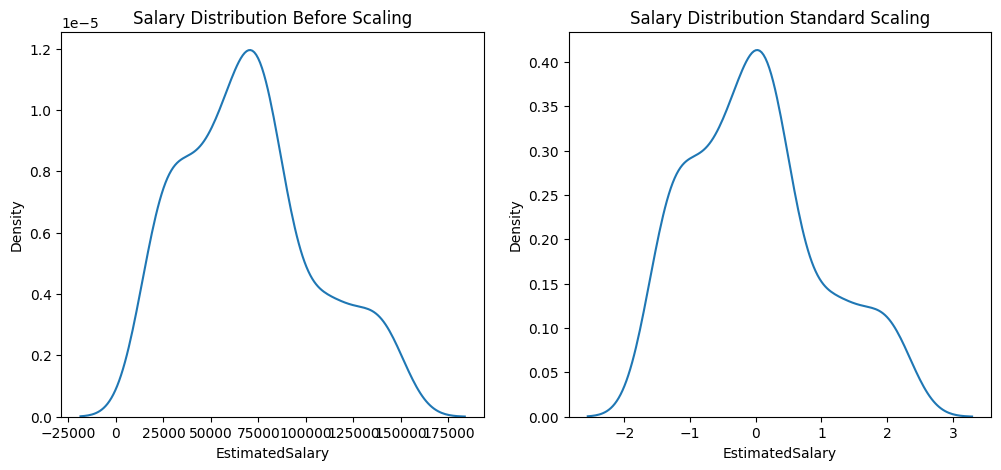

In [21]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Why scaling is important?

---

## 🔍 Does scaling help Logistic Regression?

### 📊 Setup:

* Binary classification problem: Predict `Purchased` using `Age` and `EstimatedSalary`.
* **Two Logistic Regression models** were trained:

  1. One on **unscaled (raw)** features
  2. One on **scaled (standardized)** features

---

## 📈 Observed Results (From Transcript)

> **Without Scaling**: Accuracy ≈ 65%
> **With Standard Scaling**: Accuracy ≈ 86%

---

## ✅ Why Does Scaling Improve Logistic Regression?

### 🔧 1. Logistic Regression Uses Gradient Descent

* Logistic Regression is **optimized using gradient descent**, which:

  * Is **sensitive to feature scale**
  * Can **converge slowly** or even get stuck if one feature dominates the gradient

> Transcript:

> 🔁 When a feature has a large scale, gradient descent updates weights unevenly.

---

### 📐 2. Unscaled Features Lead to Skewed Decision Boundaries

Example:

* `Age` ranges from 18–60
* `Salary` ranges from ₹15,000–₹200,000

> Without scaling:

* Salary will dominate the model coefficients
* Model may **ignore age**, even if it’s important
* The **decision boundary is biased**

> With scaling:

* Both features are brought to **mean = 0, std = 1**
* Model learns more **balanced coefficients**
* The **decision boundary is more accurate**

---

### 🔍 3. Interpretability & Regularization

* Regularized Logistic Regression penalizes large coefficients
* Without scaling, the penalty unfairly affects features with small scales
* Scaling **makes regularization fair** across all features

---

## 🧠 Transcript Insight:

> 🔁 After scaling using the scaler, Logistic Regression accuracy improved...

> 🔁 Without scaling, the optimization doesn't converge properly...

---

## ✅ Summary Table

| Feature                      | Without Scaling      | With Standard Scaling   |
| ---------------------------- | -------------------- | ----------------------- |
| Gradient Descent Behavior    | Skewed updates       | Smooth, efficient       |
| Model Accuracy               | \~65%                | \~86%                   |
| Coefficient Interpretability | Unbalanced           | Balanced                |
| Decision Boundary            | Biased toward salary | Fair between age/salary |

---

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [24]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [25]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [26]:
from sklearn.metrics import accuracy_score

In [27]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.875
Scaled 0.8666666666666667


**⚠️ My Caution:**

My Actuals was lot higher that what the instructor got. Scaling in my case reduced accuracy. But in reality for larger datasets it should.

## 🔍 Does scaling help in Decision Trees?

It does not as demonstrated here

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [30]:
dt.fit(X_train,y_train)
dt_scaled.fit(X_train_scaled,y_train)

DecisionTreeClassifier()

In [31]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [32]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8666666666666667
Scaled 0.875


# Effect of Outlier

In [33]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


### Added few outliers

In [34]:
import pandas as pd

# Original DataFrame
# df = pd.DataFrame({
#     'Age': [27, 15, 33, 63, 90],
#     'EstimatedSalary': [48000, 32000, 54000, 83000, 92000],
#     'Purchased': [0, 0, 0, 1, 1]
# })

# New rows to add
new_data = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

# Append using pd.concat
df = pd.concat([df, new_data], ignore_index=True)

# Show the result
df


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


### Visualize the outliers before scaling

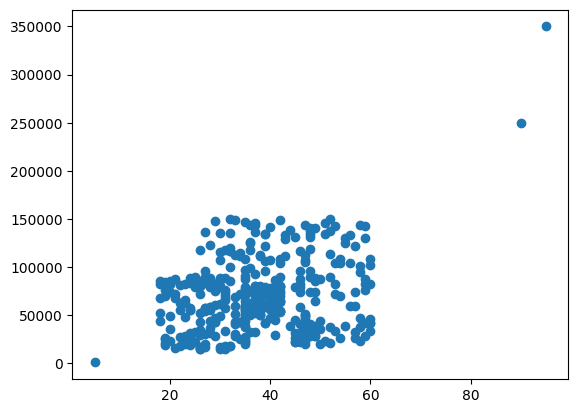

In [37]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 2), (121, 2))

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

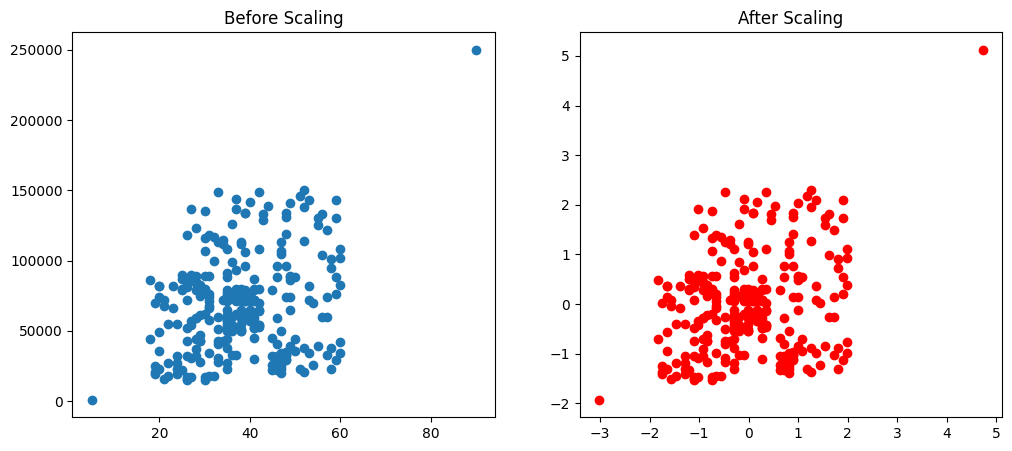

In [41]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

**❗ Observation:**

Standardization has no impact on outliers